# Lending Club — EDA & Data Preparation Pipeline
### Customer Segmentation & Credit Risk Analytics
**Author:** Hiral Sarkar &nbsp;|&nbsp; MSc Global Financial Markets &nbsp;|&nbsp; PG Data Science & AI

**Dataset:** Lending Club `lending_club_dataset.csv` (22,60,000+ records)

**Goal:** Clean and enrich the raw loan-level data, engineer credit-risk and campaign-analytics features, run exploratory analysis, and export model-ready tables for the Power BI dashboard.

**Outputs:**
- `cleaned_lending_club.csv` — main Power BI import
- `segment_summary.csv` — grade-level summary
- `state_summary.csv` — geographic risk summary

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.dpi'] = 110

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Load Data

In [37]:
DATA_PATH = r"C:\Users\hiral\Downloads\files\lending_club_dataset.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: 2,260,701 rows x 151 columns


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,"3,600.00","3,600.00","3,600.00",36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,"55,000.00",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,675.00,679.00,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,"24,700.00","24,700.00","24,700.00",36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,"65,000.00",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.00,Dec-1999,715.00,719.00,4.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,"20,000.00","20,000.00","20,000.00",60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,"63,000.00",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.00,Aug-2000,695.00,699.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,"35,000.00","35,000.00","35,000.00",60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,"110,000.00",Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.00,Sep-2008,785.00,789.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,"10,400.00","10,400.00","10,400.00",60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,"104,433.00",Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.37,1.00,Jun-1998,695.00,699.00,3.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Select Relevant Columns
Keep only the fields needed for credit-risk scoring, segmentation, and campaign analytics.

In [38]:
COLS = [
    # Borrower identifiers
    'id', 'member_id',
    # Loan characteristics
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'purpose', 'loan_status',
    # Borrower financials
    'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'open_acc', 'total_acc', 'revol_bal', 'revol_util',
    'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'recoveries',
    # Employment
    'emp_length', 'home_ownership',
    # Geography
    'addr_state', 'zip_code',
    # Dates
    'issue_d', 'last_pymnt_d', 'earliest_cr_line',
    # Credit event
    'chargeoff_within_12_mths', 'pub_rec', 'collections_12_mths_ex_med'
]

# Keep only columns that exist in this version of the dataset
COLS = [c for c in COLS if c in df.columns]
df = df[COLS].copy()
print(f"Selected {len(COLS)} relevant columns")

Selected 34 relevant columns


## 3. Clean & Type Conversions
Parse percentages, term lengths, employment tenure, dates, and compute the FICO midpoint.

In [39]:
# Strip % from interest rate and revol_util
for col in ['int_rate', 'revol_util']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse term to integer months
if 'term' in df.columns:
    df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)

# Parse emp_length to numeric years
if 'emp_length' in df.columns:
    df['emp_years'] = df['emp_length'].str.extract(r'(\d+)').astype(float)
    df.loc[df['emp_length'] == '< 1 year', 'emp_years'] = 0

# Parse dates
for col in ['issue_d', 'last_pymnt_d', 'earliest_cr_line']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')

# FICO midpoint
if 'fico_range_low' in df.columns and 'fico_range_high' in df.columns:
    df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2

print("Type conversions complete")
df[['int_rate', 'revol_util', 'term_months', 'emp_years', 'fico_score']].describe()

Type conversions complete


,int_rate,revol_util,term_months,emp_years,fico_score
count,"2,260,668.00","2,258,866.00","2,260,668.00","2,113,761.00","2,260,668.00"
mean,13.09,50.34,42.91,5.93,700.59
std,4.83,24.71,10.87,3.72,33.01
min,5.31,0.00,36.00,0.00,612.00
25%,9.49,31.50,36.00,2.00,677.00
50%,12.62,50.30,36.00,6.00,692.00
75%,15.99,69.40,60.00,10.00,717.00
max,30.99,892.30,60.00,10.00,847.50


## 4. Handle Missing Values
Drop columns that are mostly empty, then impute numeric columns with the median and categorical columns with the mode.

In [40]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Missing values (%):")
missing_pct.head(10)

Missing values (%):


member_id                    100.00
emp_length                     6.50
emp_years                      6.50
last_pymnt_d                   0.11
dti                            0.08
revol_util                     0.08
chargeoff_within_12_mths       0.01
collections_12_mths_ex_med     0.01
dtype: float64

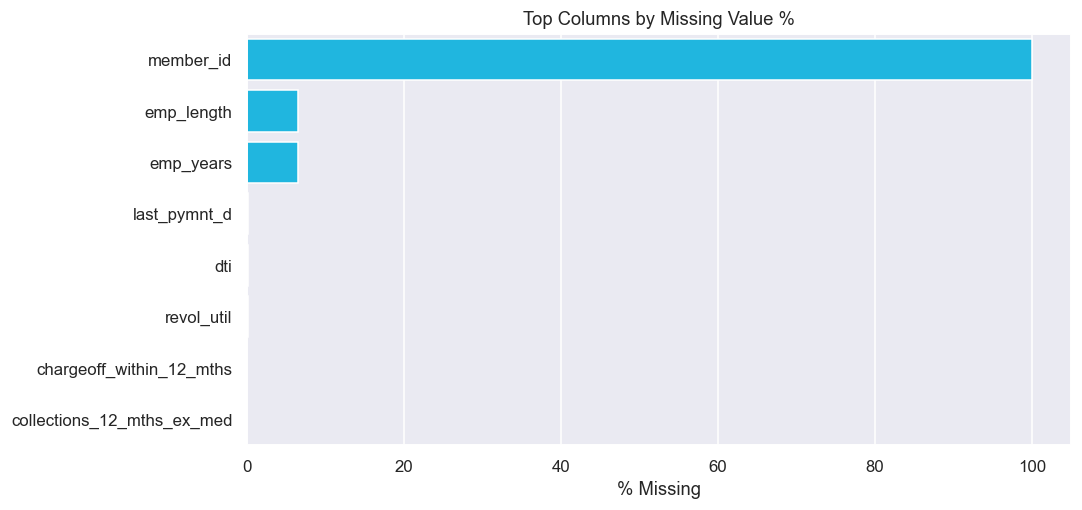

In [41]:
if len(missing_pct):
    n = len(missing_pct.head(10))
    fig_h = max(2, n * 0.6)
    plt.figure(figsize=(10, fig_h))
    top = missing_pct.head(10).rename_axis(None)
    sns.barplot(x=top.values, y=top.index, color='#00c8ff')
    plt.xlabel('% Missing')
    plt.ylabel('')
    plt.title('Top Columns by Missing Value %')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot.")

In [42]:
# Drop columns with >50% missing
drop_thresh = len(df) * 0.5
df = df.dropna(thresh=drop_thresh, axis=1)

# Fill numeric with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

print(f"Missing values handled. Shape: {df.shape}")

Missing values handled. Shape: (2260701, 36)


## 5. Default / Charge-Off Flags & Loss Metrics
Build the credit-event flags and the LGD / Expected-Loss proxies used throughout the dashboard.

In [43]:
DEFAULT_STATUSES = [
    'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)', 'Late (16-30 days)'
]

df['is_default'] = df['loan_status'].isin(DEFAULT_STATUSES).astype(int)
df['is_chargeoff'] = (df['loan_status'] == 'Charged Off').astype(int)
df['is_current'] = (df['loan_status'] == 'Current').astype(int)
df['is_fully_paid'] = (df['loan_status'] == 'Fully Paid').astype(int)

# Loss given default (simplified LGD proxy)
if 'total_pymnt' in df.columns and 'funded_amnt' in df.columns:
    df['recovery_rate'] = np.where(
        df['funded_amnt'] > 0,
        df['total_pymnt'] / df['funded_amnt'],
        0
    ).clip(0, 1)
    df['lgd_proxy'] = 1 - df['recovery_rate']

# EL proxy = PD (default flag) x LGD x EAD
if 'lgd_proxy' in df.columns:
    df['el_proxy'] = df['is_default'] * df['lgd_proxy'] * df['funded_amnt']

print("Default, charge-off, and loss flags created")
df[['is_default', 'is_chargeoff', 'is_current', 'is_fully_paid']].mean().mul(100).round(2)

Default, charge-off, and loss flags created


is_default      13.06
is_chargeoff    11.88
is_current      38.85
is_fully_paid   47.63
dtype: float64

## 6. Customer Segmentation
Derive the risk segment (Prime → Deep Subprime), income band, FICO band, DTI band, loan-size band, and an early-warning watchlist flag.

In [44]:
# --- Risk Segment (by grade) ---
risk_map = {
    'A': 'Prime', 'B': 'Near-Prime', 'C': 'Near-Prime',
    'D': 'Subprime', 'E': 'Subprime',
    'F': 'Deep Subprime', 'G': 'Deep Subprime'
}
if 'grade' in df.columns:
    df['risk_segment'] = df['grade'].map(risk_map).fillna('Unknown')

# --- Income Band ---
if 'annual_inc' in df.columns:
    df['income_band'] = pd.cut(
        df['annual_inc'],
        bins=[0, 30000, 60000, 100000, 200000, float('inf')],
        labels=['<30K', '30K-60K', '60K-100K', '100K-200K', '200K+']
    )

# --- FICO Band ---
if 'fico_score' in df.columns:
    df['fico_band'] = pd.cut(
        df['fico_score'],
        bins=[0, 580, 669, 739, 799, 850],
        labels=['Poor (<580)', 'Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Exceptional (800+)']
    )

# --- DTI Risk Band ---
if 'dti' in df.columns:
    df['dti_band'] = pd.cut(
        df['dti'],
        bins=[-1, 15, 25, 35, float('inf')],
        labels=['Low (<15)', 'Moderate (15-25)', 'High (25-35)', 'Very High (>35)']
    )

# --- Loan Size Band ---
if 'loan_amnt' in df.columns:
    df['loan_size_band'] = pd.cut(
        df['loan_amnt'],
        bins=[0, 5000, 15000, 25000, 35000, float('inf')],
        labels=['Micro (<5K)', 'Small (5K-15K)', 'Medium (15K-25K)', 'Large (25K-35K)', 'Jumbo (>35K)']
    )

# --- Watchlist Flag (early warning signal) ---
watchlist_conditions = []
if 'delinq_2yrs' in df.columns:
    watchlist_conditions.append(df['delinq_2yrs'] > 0)
if 'dti' in df.columns:
    watchlist_conditions.append(df['dti'] > 30)
if 'revol_util' in df.columns:
    watchlist_conditions.append(df['revol_util'] > 80)
if 'int_rate' in df.columns:
    watchlist_conditions.append(df['int_rate'] > 20)

if watchlist_conditions:
    watchlist_mask = watchlist_conditions[0]
    for cond in watchlist_conditions[1:]:
        watchlist_mask = watchlist_mask | cond
    df['watchlist_flag'] = watchlist_mask.astype(int)
else:
    df['watchlist_flag'] = 0

print("Customer segments created")
df['risk_segment'].value_counts()

Customer segments created


risk_segment
Near-Prime       1313643
Subprime          460063
Prime             433027
Deep Subprime      53968
Name: count, dtype: int64

## 7. Campaign Response Proxy
"Responded" = funded loan with grade A/B/C (creditworthy); "high value" = grade A/B with above-median income.

In [45]:
if 'grade' in df.columns:
    df['campaign_response'] = df['grade'].isin(['A', 'B', 'C']).astype(int)
    df['high_value_customer'] = (
        (df['grade'].isin(['A', 'B'])) &
        (df['annual_inc'] > df['annual_inc'].median() if 'annual_inc' in df.columns else True)
    ).astype(int)

print("Campaign response proxies created")
print(f"Campaign response rate: {df['campaign_response'].mean():.1%}")
print(f"High-value customer rate: {df['high_value_customer'].mean():.1%}")

Campaign response proxies created
Campaign response rate: 77.3%
High-value customer rate: 26.0%


## 8. Feature Engineering
Credit history length, payment-to-income ratio, and account utilisation ratio.

In [46]:
if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
    df['credit_history_months'] = (
        (df['issue_d'] - df['earliest_cr_line']).dt.days / 30
    ).clip(0)

if 'annual_inc' in df.columns and 'installment' in df.columns:
    df['payment_to_income'] = (df['installment'] * 12) / df['annual_inc'].replace(0, np.nan)

if 'total_acc' in df.columns and 'open_acc' in df.columns:
    df['utilization_ratio'] = df['open_acc'] / df['total_acc'].replace(0, np.nan)

print("Engineered features created")
df[['credit_history_months', 'payment_to_income', 'utilization_ratio']].describe()

Engineered features created


,credit_history_months,payment_to_income,utilization_ratio
count,"2,260,639.00","2,259,034.00","2,260,701.00"
mean,199.60,0.20,0.52
std,93.50,30.30,0.18
min,6.13,0.00,0.00
25%,137.00,0.05,0.39
50%,180.60,0.07,0.50
75%,246.57,0.11,0.64
max,"1,013.60","14,270.88",1.75


## 9. Exploratory Data Analysis
Visual checks on the key risk drivers before exporting to Power BI.

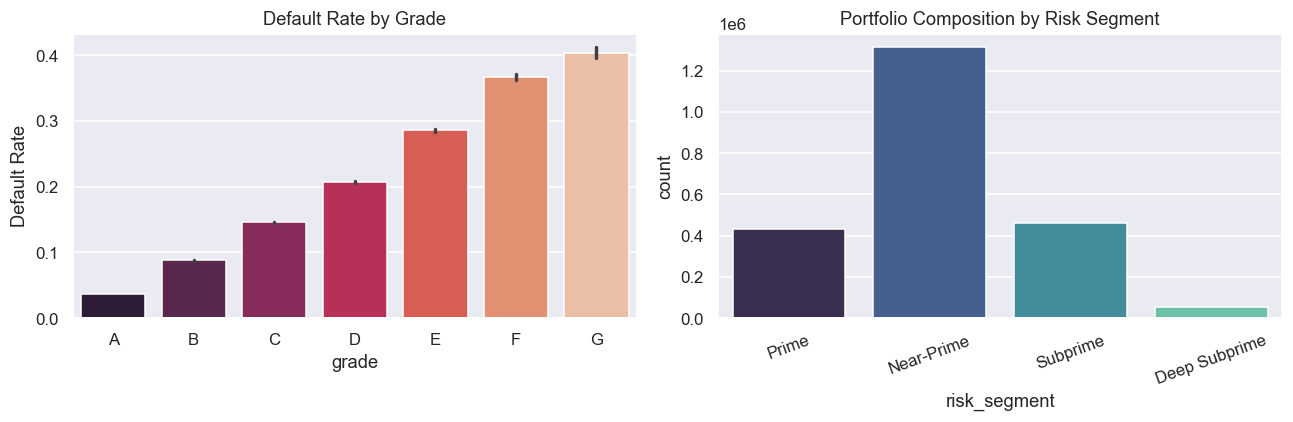

In [29]:
# Default rate by grade & portfolio composition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = sorted(df['grade'].dropna().unique())
sns.barplot(x='grade', y='is_default', data=df, order=order, ax=axes[0], palette='rocket')
axes[0].set_title('Default Rate by Grade')
axes[0].set_ylabel('Default Rate')

sns.countplot(x='risk_segment', data=df,
               order=['Prime', 'Near-Prime', 'Subprime', 'Deep Subprime'],
               ax=axes[1], palette='mako')
axes[1].set_title('Portfolio Composition by Risk Segment')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

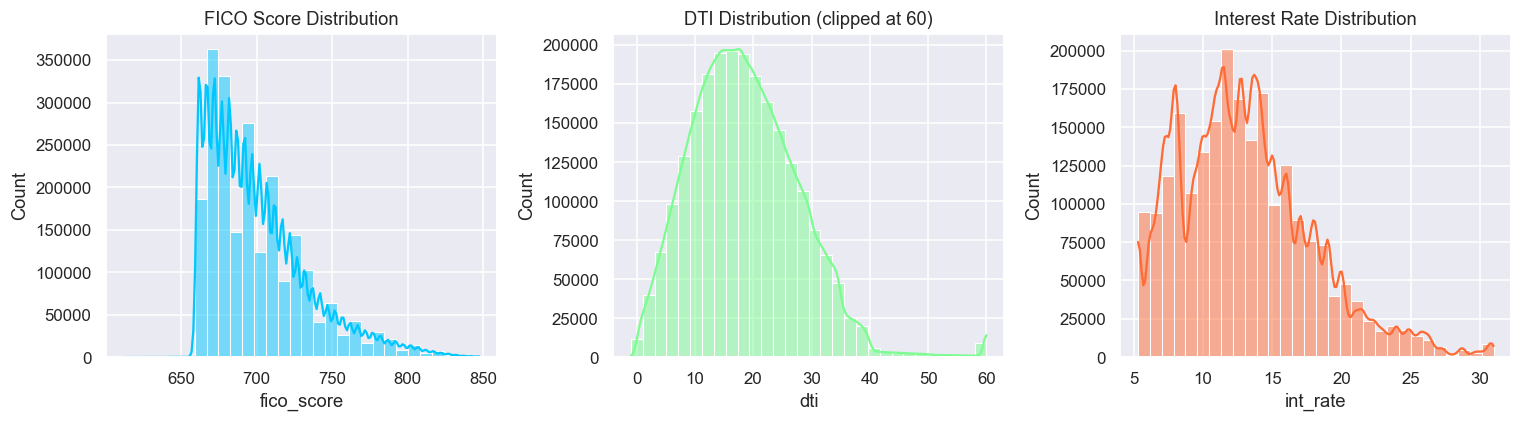

In [30]:
# Distribution of key numeric drivers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df['fico_score'], bins=30, kde=True, ax=axes[0], color='#00c8ff')
axes[0].set_title('FICO Score Distribution')

sns.histplot(df['dti'].clip(upper=60), bins=30, kde=True, ax=axes[1], color='#7cfc91')
axes[1].set_title('DTI Distribution (clipped at 60)')

sns.histplot(df['int_rate'], bins=30, kde=True, ax=axes[2], color='#ff6b35')
axes[2].set_title('Interest Rate Distribution')

plt.tight_layout()
plt.show()

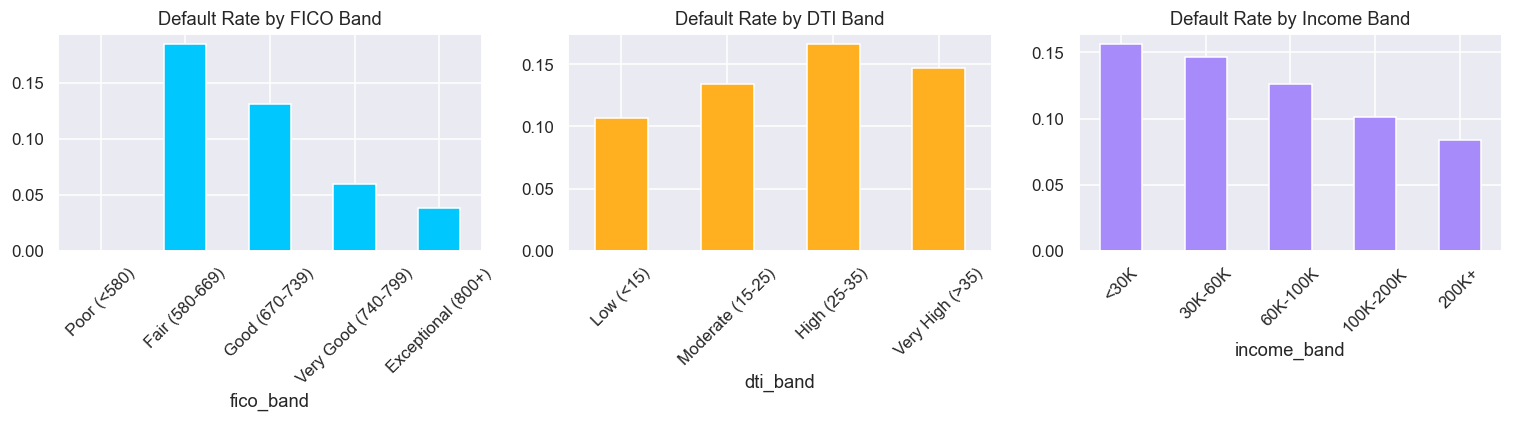

In [31]:
# Default rate across FICO, DTI and income bands
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('fico_band')['is_default'].mean().plot(kind='bar', ax=axes[0], color='#00c8ff')
axes[0].set_title('Default Rate by FICO Band')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('dti_band')['is_default'].mean().plot(kind='bar', ax=axes[1], color='#ffb020')
axes[1].set_title('Default Rate by DTI Band')
axes[1].tick_params(axis='x', rotation=45)

df.groupby('income_band')['is_default'].mean().plot(kind='bar', ax=axes[2], color='#a78bfa')
axes[2].set_title('Default Rate by Income Band')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

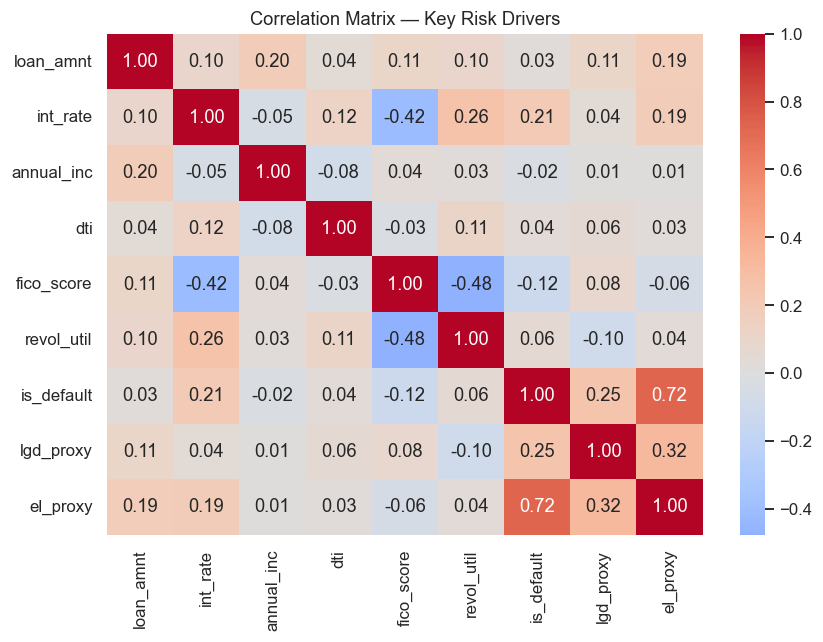

In [32]:
# Correlation heatmap of key risk variables
risk_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_score',
              'revol_util', 'is_default', 'lgd_proxy', 'el_proxy']
risk_cols = [c for c in risk_cols if c in df.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df[risk_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Key Risk Drivers')
plt.tight_layout()
plt.show()

## 10. EDA Summary Statistics

In [33]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"\nTotal Records: {len(df):,}")
print(f"Default Rate: {df['is_default'].mean():.2%}")
print(f"Charge-Off Rate: {df['is_chargeoff'].mean():.2%}")
print(f"Watchlist Accounts: {df['watchlist_flag'].sum():,} ({df['watchlist_flag'].mean():.2%})")

if 'loan_amnt' in df.columns:
    print(f"\nPortfolio Size (Total Loan Amount): ${df['loan_amnt'].sum():,.0f}")
    print(f"Avg Loan Size: ${df['loan_amnt'].mean():,.0f}")

if 'int_rate' in df.columns:
    print(f"Avg Interest Rate: {df['int_rate'].mean():.2f}%")

if 'annual_inc' in df.columns:
    print(f"Avg Annual Income: ${df['annual_inc'].median():,.0f} (median)")

if 'grade' in df.columns:
    print("\nDefault Rate by Grade:")
    print(df.groupby('grade')['is_default'].mean().apply(lambda x: f"{x:.2%}"))

if 'purpose' in df.columns:
    print("\nTop 5 Loan Purposes:")
    print(df['purpose'].value_counts().head(5))

EDA SUMMARY

Total Records: 2,260,701
Default Rate: 13.06%
Charge-Off Rate: 11.88%
Watchlist Accounts: 930,342 (41.15%)

Portfolio Size (Total Loan Amount): $34,016,541,625
Avg Loan Size: $15,047
Avg Interest Rate: 13.09%
Avg Annual Income: $65,000 (median)

Default Rate by Grade:
grade
A     3.67%
B     8.81%
C    14.59%
D    20.65%
E    28.58%
F    36.73%
G    40.33%
Name: is_default, dtype: object

Top 5 Loan Purposes:
purpose
debt_consolidation    1277910
credit_card            516971
home_improvement       150457
other                  139440
major_purchase          50445
Name: count, dtype: int64


## 11. Export for Power BI
Writes the main cleaned dataset plus grade-level and state-level summary tables for the dashboard.

In [47]:
# Convert categoricals to string for Power BI compatibility
cat_segment_cols = ['income_band', 'fico_band', 'dti_band', 'loan_size_band']
for col in cat_segment_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Fix 1: Cap payment_to_income outliers (installments > annual income = data anomaly)
if 'payment_to_income' in df.columns:
    df['payment_to_income'] = df['payment_to_income'].clip(upper=1.0)

# Fix 2: Fill credit_history_months nulls (62 rows; created after main imputation, so missed)
if 'credit_history_months' in df.columns:
    df['credit_history_months'] = df['credit_history_months'].fillna(df['credit_history_months'].median())

# Fix 3: Sample 150K rows stratified by grade — full 2.26M rows = 897 MB, too large for Power BI
df_pbi = (
    df.groupby('grade', group_keys=False)
      .apply(lambda x: x.sample(frac=150_000 / len(df), random_state=33))
      .reset_index(drop=True)
)
print(f"Stratified sample: {len(df_pbi):,} rows")
print(df_pbi['grade'].value_counts().sort_index())
print(f"Default rate in sample: {df_pbi['is_default'].mean():.2%} (full: {df['is_default'].mean():.2%})")

# Main export
output_path = "cleaned_lending_club.csv"
df_pbi.to_csv(output_path, index=False)
print(f"\nMain export: {output_path} ({len(df_pbi):,} rows)")

# Segment summary — use full df for accurate population-level rates
if 'risk_segment' in df.columns and 'grade' in df.columns:
    seg_summary = df.groupby(['grade', 'risk_segment']).agg(
        loan_count=('id', 'count') if 'id' in df.columns else ('loan_amnt', 'count'),
        total_loan_amnt=('loan_amnt', 'sum'),
        avg_int_rate=('int_rate', 'mean'),
        default_rate=('is_default', 'mean'),
        avg_fico=('fico_score', 'mean') if 'fico_score' in df.columns else ('fico_range_low', 'mean'),
        watchlist_count=('watchlist_flag', 'sum'),
    ).reset_index()
    seg_summary.to_csv("segment_summary.csv", index=False)
    print("Segment summary: segment_summary.csv")

# State-level summary — use full df, drop states with <100 loans (unreliable rates)
if 'addr_state' in df.columns:
    state_summary = df.groupby('addr_state').agg(
        loan_count=('loan_amnt', 'count'),
        total_amnt=('loan_amnt', 'sum'),
        default_rate=('is_default', 'mean'),
        avg_int_rate=('int_rate', 'mean'),
    ).reset_index()
    state_summary = state_summary[state_summary['loan_count'] >= 100]
    state_summary.to_csv("state_summary.csv", index=False)
    print(f"State summary: state_summary.csv ({len(state_summary)} states)")

print("\nPIPELINE COMPLETE — Import cleaned_lending_club.csv into Power BI")

Stratified sample: 150,000 rows
grade
A    28732
B    44030
C    43132
D    21526
E     9000
F     2773
G      807
Name: count, dtype: int64
Default rate in sample: 12.94% (full: 13.06%)

Main export: cleaned_lending_club.csv (150,000 rows)
Segment summary: segment_summary.csv
State summary: state_summary.csv (50 states)

PIPELINE COMPLETE — Import cleaned_lending_club.csv into Power BI
